# 300. Validate depletion_q baseline re-evaluation

This notebook starts the final `depletion_q` version of the transmissivity uncertainty workflow.

The earlier `fish_dollars` workflow was useful for building and debugging the method, but the final project objective is hydrologic: **Little Plover streamflow/depletion versus total pumping**. The `depletion_q` objective is better aligned with that goal.

The purpose of this notebook is to validate the baseline re-evaluation workflow before changing transmissivity.

In plain language, this notebook asks:

> If we take the original `depletion_q` baseline Pareto-front pumping designs and re-run them through the original PyCap forward model with the same baseline T, do we reproduce the archived pumping, depletion, and streamflow values?

If this validation works, then the later notebooks can safely use the same re-evaluation machinery for T uncertainty.


**Important pumping-objective note:** for `depletion_q`, the archived `obj_well` objective is the sum of only the decision-variable pumping parameters. It is not the sum of all pumping in the full PyCap model. The notebook therefore validates the archived pumping objective against the re-evaluated decision-variable pumping sum.


## 1. Imports, helper reload, and user controls

This section imports the depletion-q helper module, creates output/cache folders, and defines the baseline run that we want to validate.

A key difference from the fish-dollars workflow is that we use the original depletion-q forward script:

```text
run_pycap_standalone_opt_mou.py
```

not the fish-dollars script:

```text
run_pycap_standalone_opt_mou_fish_dollars.py
```

That matters because the depletion-q objective only needs the pumping decision variables and depletion observations. It does not calculate fish probability or agricultural receipts.

In [9]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------------------------------------------------------
# Force a clean helper import.
# This avoids Jupyter accidentally reusing an older helper module from memory.
# -----------------------------------------------------------------------------
sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()

import uncertainty_project_helpers_depletion_q as up

print("Imported helper from:", Path(up.__file__).resolve())
print("Helper version:", up.HELPER_VERSION)

# -----------------------------------------------------------------------------
# User controls
# -----------------------------------------------------------------------------
RUN_NAME = "depletion_q_baseline_0.0_1.0_0.01"

# If True, rerun each Pareto member through PyCap.
# If False, load the cached validation table if it already exists.
RERUN_REEVALUATION = False

# Optional debugging switch. Use a small number like 5 while testing.
# Set to None for the full final front.
N_TEST_MEMBERS = None

# Validation tolerances.
# Pumping uses a slightly relaxed tolerance because the archived obj_well value
# and the re-computed decision-variable pumping sum can differ at about 1e-4 cfs
# from rounding/precision in saved files. This is about 0.05 gpm and is not
# meaningful hydrologically.
PUMPING_ABS_TOL_CFS = 1.0e-3

# Depletion is the primary hydrologic validation target for depletion_q.
# Streamflow is computed from depletion, so it is kept as a diagnostic only.
DEPLETION_ABS_TOL_CFS = 1.0e-5

# Apply project plotting defaults.
up.apply_plot_style()

# Standard paths.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = up.find_lpr_pycap_opt_dir(NOTEBOOK_DIR)
dirs = up.make_project_dirs(
    notebook_dir=NOTEBOOK_DIR,
    notebook_number="300",
    notebook_slug="validate_depletion_q_baseline_reevaluation",
)
OUTPUT_DIR = dirs["output_dir"]
CACHE_DIR = dirs["cache_dir"]

CACHE_FILE = CACHE_DIR / "300_depletion_q_baseline_reevaluation.csv"
ERROR_FILE = CACHE_DIR / "300_depletion_q_baseline_reevaluation_errors.csv"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)

Imported helper from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-24_depletion_q_304_v7_full_uncertainty_annotation_higher
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/300_validate_depletion_q_baseline_reevaluation
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/cached_reevaluations/300_depletion_q_baseline_reevaluation.csv


## 2. Load the depletion_q baseline run context and Pareto designs

This section loads the original `depletion_q` baseline run.

The important source file is:

```text
pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01/depletion_q_baseline_0.0_1.0_0.01.pareto.archive.summary.csv.zip
```

The Pareto archive contains the optimized front members. The decision-variable population files contain the actual well-by-well pumping designs for those members.

We select the final-generation, feasible, front-1 members as the design set for validation.

In [10]:
# Load the original run context.
# The context includes:
#   - original PyCap input dictionary
#   - depletion observations used by PEST++
#   - original forward script module
#   - baseline T value
context = up.load_depletion_q_context(RUN_NAME, project_dir=PROJECT_DIR)

print("Run directory:", context.run_dir)
print("Forward script:", context.script_path)
print("Baseline T:", context.base_T)
print("Number of observation names:", len(context.obsnames))
print("First few observations:", context.obsnames[:5])

# Read the PEST++ MOU Pareto archive and select final feasible front-1 members.
pareto_archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(
    pareto_archive,
    depletion_obs_name=up.DEPLETION_OBS_NAME,
    n_test_members=N_TEST_MEMBERS,
)

# Load the saved decision-variable populations and identify pumping columns.
dv_df = up.load_decision_variable_population(context.run_dir)
q_cols = up.get_q_columns(dv_df)

print("Archive rows:", len(pareto_archive))
print("Final feasible front-1 members:", len(pareto_final))
print("Decision-variable population shape:", dv_df.shape)
print("Number of pumping columns in population file:", len(q_cols))
print("Number of PEST decision-variable pumping columns:", len(context.decvar_q_cols))
print("Number of fixed/background pumping columns:", len(context.fixed_q_cols))

# Quick display so we can see the key archived objective columns.
# `obj_well` is in gpm in the raw archive; multiply by GPM2CFS to get cfs.
preview = pareto_final[["member", "generation", "obj_well", up.DEPLETION_OBS_NAME]].head().copy()
preview["obj_well_cfs"] = preview["obj_well"] * up.GPM2CFS
display(preview)

Run directory: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01
Forward script: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01/run_pycap_standalone_opt_mou.py
Baseline T: 1700.0
Number of observation names: 330
First few observations: ['lpr:418:bdpl', 'lpr:466:bdpl', 'lpr:467:bdpl', 'lpr:490:bdpl', 'lpr:509:bdpl']
Archive rows: 8809
Final feasible front-1 members: 296
Decision-variable population shape: (8772, 327)
Number of pumping columns in population file: 327
Number of PEST decision-variable pumping columns: 86
Number of fixed/background pumping columns: 241


,member,generation,obj_well,lpr:total_combined:bdpl,obj_well_cfs
8495,152,50,17542.80,4.782580,39.085358
8496,gen=36_member=6021_pso,50,7060.34,0.811083,15.730438
8497,16,50,17265.50,4.489270,38.467534
8498,130,50,17325.00,4.690710,38.600100
8499,95,50,17459.90,4.701270,38.900657


## 3. Re-evaluate the baseline Pareto designs, or load cached results

This section is the main validation run.

For each final front member, we:

1. get the member's pumping design from the decision-variable population,
2. pass the pumping design into the original `depletion_q` PyCap forward function,
3. keep T at the baseline value,
4. compute depletion and streamflow,
5. compute the **pumping objective** as the sum of the PEST decision-variable pumping parameters only,
6. compare those re-evaluated values to the archived values.

The key correction is step 5. The archived `obj_well` value is not full model pumping from all wells. It is the objective created by `pst.add_pi_equation(...)`, so it sums only the `decvars` pumping parameters.

Because this can take some time, the re-evaluated results are cached.


In [11]:
if RERUN_REEVALUATION or not CACHE_FILE.exists():
    scenarios = {"baseline_T": 1.0}

    results_long, error_df = up.reevaluate_depletion_q_designs(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=q_cols,
        context=context,
        scenarios=scenarios,
        historic_streamflow_cfs=up.HISTORIC_STREAMFLOW_CFS,
        depletion_obs_name=up.DEPLETION_OBS_NAME,
        progress_every=25,
    )

    results_long.to_csv(CACHE_FILE, index=False)
    up.write_error_cache(error_df, ERROR_FILE)

    print("Saved re-evaluation cache:", CACHE_FILE)
    print("Saved error table:", ERROR_FILE)
else:
    results_long = pd.read_csv(CACHE_FILE)
    if ERROR_FILE.exists():
        error_df = up.read_csv_if_not_empty(ERROR_FILE)
    else:
        error_df = pd.DataFrame()

    print("Loaded cached re-evaluation results:", CACHE_FILE)

print("results_long shape:", results_long.shape)
print("error_df shape:", error_df.shape)

display(results_long.head())
if not error_df.empty:
    display(error_df.head())

Loaded cached re-evaluation results: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/cached_reevaluations/300_depletion_q_baseline_reevaluation.csv
results_long shape: (296, 23)
error_df shape: (0, 4)


,scenario,T_factor,T_value,probability_weight,member,generation,archive_pumping_objective_gpm,archive_pumping_objective_cfs,archive_total_pumping_gpm,archive_total_pumping_cfs,...,pumping_objective_reeval_cfs,total_pumping_gpm,total_pumping_cfs,full_model_total_pumping_gpm,full_model_total_pumping_cfs,n_model_q_columns,n_objective_q_columns,depletion_obs_name,depletion_cfs,streamflow_cfs
0,baseline_T,1.0,1700.0,NaN,152,50,17542.80,39.085358,17542.80,39.085358,...,39.085441,17542.837279,39.085441,52826.737279,117.697971,327,86,lpr:total_combined:bdpl,4.782582,3.817418
1,baseline_T,1.0,1700.0,NaN,gen=36_member=6021_pso,50,7060.34,15.730438,7060.34,15.730438,...,15.730429,7060.336017,15.730429,42344.236017,94.342958,327,86,lpr:total_combined:bdpl,0.811083,7.788917
2,baseline_T,1.0,1700.0,NaN,16,50,17265.50,38.467534,17265.50,38.467534,...,38.467529,17265.497624,38.467529,52549.397624,117.080058,327,86,lpr:total_combined:bdpl,4.489274,4.110726
3,baseline_T,1.0,1700.0,NaN,130,50,17325.00,38.600100,17325.00,38.600100,...,38.600146,17325.020547,38.600146,52608.920547,117.212675,327,86,lpr:total_combined:bdpl,4.690711,3.909289
4,baseline_T,1.0,1700.0,NaN,95,50,17459.90,38.900657,17459.90,38.900657,...,38.900681,17459.910855,38.900681,52743.810855,117.513211,327,86,lpr:total_combined:bdpl,4.701268,3.898732


## 4. Build the validation comparison and summary table

This section calculates the absolute differences between archived and re-evaluated results.

The most important checks are:

- archived pumping objective, `obj_well`, versus re-evaluated decision-variable pumping objective,
- archived depletion versus re-evaluated depletion,
- archived streamflow versus re-evaluated streamflow.

For diagnostics, the re-evaluation table also stores full model pumping including fixed/background wells. That value is useful for understanding the model, but it should **not** be used to validate the archived `obj_well` objective.


In [12]:
comparison = up.build_300_validation_comparison(results_long)

validation_summary = up.summarize_300_validation(
    comparison=comparison,
    error_df=error_df,
    pumping_abs_tol_cfs=PUMPING_ABS_TOL_CFS,
    depletion_abs_tol_cfs=DEPLETION_ABS_TOL_CFS,
)

comparison_path = OUTPUT_DIR / "300_depletion_q_baseline_reevaluation_comparison.csv"
summary_path = OUTPUT_DIR / "300_depletion_q_baseline_validation_summary.csv"

comparison.to_csv(comparison_path, index=False)
validation_summary.to_csv(summary_path, index=False)

print("Saved comparison:", comparison_path)
print("Saved validation summary:", summary_path)

display(validation_summary)

print("Max pumping-objective absolute difference (cfs):", comparison["pumping_objective_abs_diff_cfs"].max())
print("Max depletion absolute difference (cfs):", comparison["depletion_abs_diff_cfs"].max())
print("Max streamflow absolute difference diagnostic (cfs):", comparison["streamflow_abs_diff_cfs"].max())

Saved comparison: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/300_validate_depletion_q_baseline_reevaluation/300_depletion_q_baseline_reevaluation_comparison.csv
Saved validation summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/300_validate_depletion_q_baseline_reevaluation/300_depletion_q_baseline_validation_summary.csv


,metric,value
0,n_members_attempted,296
1,n_members_successful,296
2,n_members_error,0
3,max_pumping_objective_abs_diff_cfs,0.000111
4,max_depletion_abs_diff_cfs,0.000005
5,max_streamflow_abs_diff_cfs_diagnostic,0.000005
6,pumping_objective_abs_tolerance_cfs,0.001
7,depletion_abs_tolerance_cfs,0.00001
8,pumping_objective_validation_passed,True
9,depletion_validation_passed,True


Max pumping-objective absolute difference (cfs): 0.00011073094297131547
Max depletion absolute difference (cfs): 4.972497019251065e-06
Max streamflow absolute difference diagnostic (cfs): 4.9724970185849315e-06


## 5. Create validation figures

This notebook now creates two figures:

1. A 1x2 validation figure comparing archived vs re-evaluated pumping objective and depletion.
2. A streamflow-front comparison, which is useful for communicating results even though the depletion_q objective is defined using depletion.


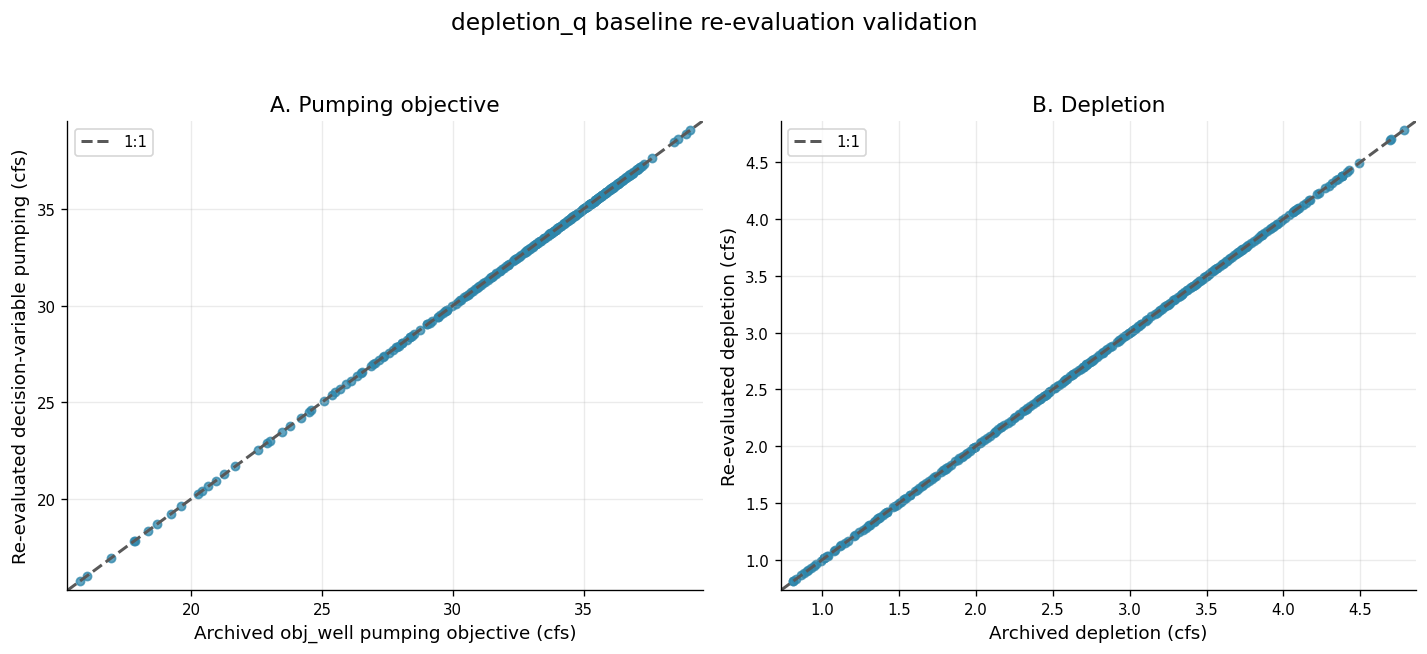

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/300_validate_depletion_q_baseline_reevaluation/300_validation_one_to_one_1x2.png


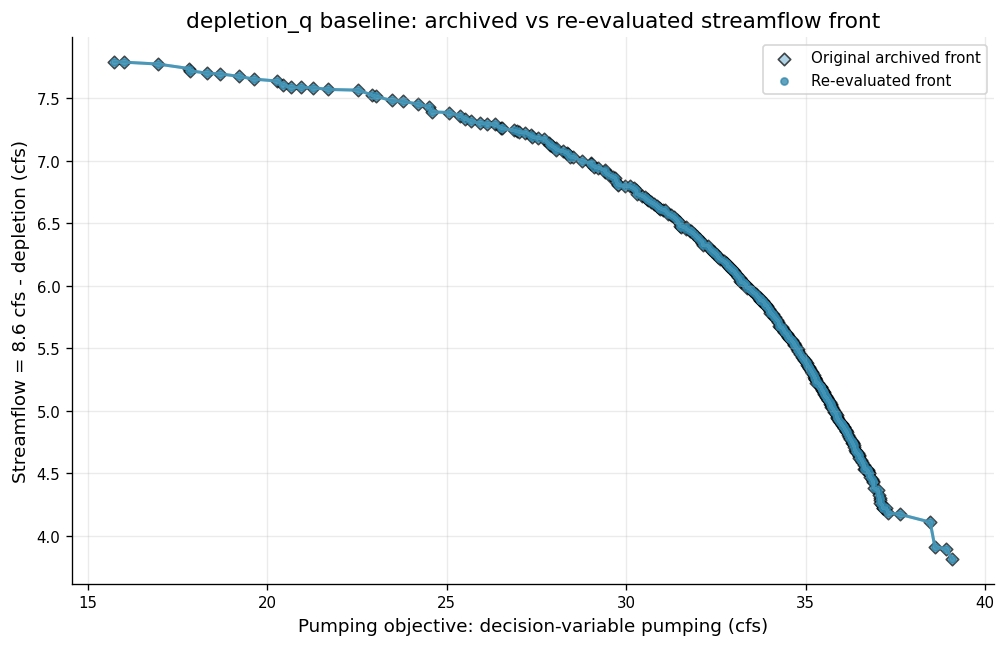

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/300_validate_depletion_q_baseline_reevaluation/300_original_vs_reevaluated_pareto_front_streamflow.png


In [13]:
# -----------------------------------------------------------------------------
# 5A. One-to-one validation plots
# -----------------------------------------------------------------------------
# For Notebook 300, validation focuses on the two quantities that define the
# depletion_q objective space:
#   1. obj_well pumping objective = sum of decision-variable pumping
#   2. depletion
# Streamflow is a direct transformation of depletion and is saved in the
# comparison CSV as a diagnostic, but it does not need a separate validation
# panel here.

plot_specs = [
    {
        "xcol": "archive_pumping_objective_cfs",
        "ycol": "pumping_objective_reeval_cfs",
        "title": "A. Pumping objective",
        "xlabel": "Archived obj_well pumping objective (cfs)",
        "ylabel": "Re-evaluated decision-variable pumping (cfs)",
    },
    {
        "xcol": "archive_depletion_cfs",
        "ycol": "depletion_cfs",
        "title": "B. Depletion",
        "xlabel": "Archived depletion (cfs)",
        "ylabel": "Re-evaluated depletion (cfs)",
    },
]

up.plot_validation_grid_1x2(
    comparison,
    plot_specs=plot_specs,
    outfile=OUTPUT_DIR / "300_validation_one_to_one_1x2.png",
    figure_title="depletion_q baseline re-evaluation validation",
)

# -----------------------------------------------------------------------------
# 5B. Original archived front vs re-evaluated front: streamflow
# -----------------------------------------------------------------------------
# Even though the objective is depletion-vs-pumping, streamflow is often the
# easier management result to communicate. It is exactly 8.6 cfs - depletion,
# so this plot tells the same story with the y-axis flipped into streamflow units.

up.plot_archive_vs_reevaluated_front(
    comparison,
    outfile=OUTPUT_DIR / "300_original_vs_reevaluated_pareto_front_streamflow.png",
    x_archive="archive_pumping_objective_cfs",
    y_archive="archive_streamflow_cfs",
    x_reeval="pumping_objective_reeval_cfs",
    y_reeval="streamflow_cfs",
    xlabel="Pumping objective: decision-variable pumping (cfs)",
    ylabel="Streamflow = 8.6 cfs - depletion (cfs)",
    title="depletion_q baseline: archived vs re-evaluated streamflow front",
)


## 6. Interpret the validation result and list final outputs

This final section prints a compact interpretation of the validation result and lists the files created by this notebook.


In [14]:
# Convenience dictionary of summary metrics.
summary_dict = dict(zip(validation_summary["metric"], validation_summary["value"]))

print("Hydrologic validation passed:", summary_dict.get("hydrologic_validation_passed"))
print("Final outputs saved in:", OUTPUT_DIR)

for path in sorted(OUTPUT_DIR.glob("300_*")):
    print(" -", path.name)

if str(summary_dict.get("hydrologic_validation_passed")).lower() == "true":
    print("Interpretation: The depletion_q baseline re-evaluation reproduced the archived pumping objective and depletion Pareto front.")
    print("It is reasonable to proceed to Notebook 301 for known T-error scenarios.")
else:
    print("Interpretation: Validation did not pass under the current tolerance settings.")
    print("Review the summary table, comparison CSV, and plots before proceeding.")


Hydrologic validation passed: True
Final outputs saved in: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/300_validate_depletion_q_baseline_reevaluation
 - 300_depletion_q_baseline_reevaluation_comparison.csv
 - 300_depletion_q_baseline_validation_summary.csv
 - 300_original_vs_reevaluated_pareto_front_streamflow.png
 - 300_validation_one_to_one_1x2.png
Interpretation: The depletion_q baseline re-evaluation reproduced the archived pumping objective and depletion Pareto front.
It is reasonable to proceed to Notebook 301 for known T-error scenarios.
